## **Predicting Loan Default Loss (Loss Given Default)**
# Business Context **bold text**
When a customer defaults on a loan, the lender does not necessarily lose the full outstanding balance. A portion of the exposure may be recovered through repayments, collateral liquidation, or legal recovery processes. However, the uncertainty around how much is ultimately recovered creates risk in capital planning, pricing, and portfolio management.

# **Problem Statement**
The organization currently faces the challenge of accurately estimating how much money is actually lost once a borrower has defaulted. Without reliable predictions, lenders may:

Hold excess regulatory capital
Under‑ or over‑price credit risk
Make suboptimal recovery and collection decisions

# **Proposed Solution**
This project proposes developing a Loss Given Default (LGD) prediction model that estimates the percentage of a loan exposure that is unrecoverable after a default has occurred. The model will use borrower characteristics, loan terms, credit history, and post‑default payment behavior to generate data‑driven LGD estimates.

# **Business Value**
Regulatory compliance: LGD is a core input in Basel III capital calculations, directly impacting risk‑weighted assets and capital requirements.

Capital efficiency: More accurate LGD estimates enable better alignment between true risk and capital held.

Improved risk management: Helps identify high‑loss segments and prioritize recovery strategies.

Better pricing and portfolio decisions: Supports risk‑based pricing and improves expected loss forecasting.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns


In [ ]:
dataset = pd.read_csv("/content/accepted_2007_to_2018Q4.csv")

In [ ]:
dataset.head()

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906367 entries, 0 to 906366
Columns: 151 entries, id to settlement_term
dtypes: float64(110), object(41)
memory usage: 1.0+ GB


In [ ]:
dataset.shape

(906367, 151)

In [ ]:
list(dataset.columns)

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [ ]:
dataset["loan_status"].value_counts()

,count
loan_status,
Fully Paid,416798
Current,364884
Charged Off,110418
Late (31-120 days),9037
In Grace Period,3465
Late (16-30 days),1737
Default,17


# **CREATING TARGET VARIABLE**

In [ ]:
default_status = ["Charged Off", "Default", "Charge"]

In [ ]:
df = dataset[dataset['loan_status'].isin(default_status)].copy()

In [ ]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
13,66624733,NaN,18000.0,18000.0,18000.0,60 months,19.48,471.70,E,E2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
25,67849662,NaN,4225.0,4225.0,4225.0,36 months,14.85,146.16,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
30,67715283,NaN,16000.0,16000.0,16000.0,36 months,12.88,538.18,C,C2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
31,68341789,NaN,24250.0,24250.0,24250.0,60 months,24.24,701.01,F,F3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
33,68415473,NaN,25000.0,25000.0,25000.0,60 months,13.99,581.58,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(110435, 151)

# **Compute LGD = LGD = 1 - (total_pymnt / funded_amnt)**
Total_pymnt includes: principal repaid + interest + late fees + recoveries
Funded_amnt is the actual amount disbursed to borrower


In [ ]:
df['recovery_rate'] = df['total_pymnt'] / df['funded_amnt']
df['LGD'] = 1 - df['recovery_rate']

In [ ]:
# Count Anomalies
n_neg = (df['LGD']<0).sum()
n_over = (df['LGD']>1).sum()

print(f" Over_recovery percentage: {n_neg} : ({(n_neg)/(len(df)*100):.2}%)")
print(f" Loss exceeds exposure: {n_over} : ({(n_over)/(len(df)*100):.2}%)")

 Over_recovery percentage: 6183 : (0.00056%)
 Loss exceeds exposure: 0 : (0.0%)


In [ ]:
#Clean target
df['LGD_RAW'] = df['LGD'].copy()
df['LGD'] = df['LGD'].clip(0,1)

In [ ]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,recovery_rate,LGD,LGD_RAW
13,66624733,NaN,18000.0,18000.0,18000.0,60 months,19.48,471.70,E,E2,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0.525152,0.474848,0.474848
25,67849662,NaN,4225.0,4225.0,4225.0,36 months,14.85,146.16,C,C5,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0.605650,0.394350,0.394350
30,67715283,NaN,16000.0,16000.0,16000.0,36 months,12.88,538.18,C,C2,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1.087289,0.000000,-0.087289
31,68341789,NaN,24250.0,24250.0,24250.0,60 months,24.24,701.01,F,F3,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0.170079,0.829921,0.829921
33,68415473,NaN,25000.0,25000.0,25000.0,60 months,13.99,581.58,C,C4,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0.579637,0.420363,0.420363


In [ ]:
print(f"MEAN: {(df["LGD"].mean()):.2f})")
print(f"MEDIAN: {(df["LGD"].median()):.2f})")

MEAN: 0.47)
MEDIAN: 0.51)


In [ ]:
leakage_cols = [
    # Payment outcomes (used to compute target)
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'out_prncp', 'out_prncp_inv',
    # Post-origination dates and status
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'loan_status',
    # Settlement info (post-default)
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    # Hardship program (post-default intervention)
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date',
    'hardship_end_date', 'payment_plan_start_date', 'hardship_length',
    'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    # Computed columns
    'recovery_rate', 'LGD_raw',
]

# --- IDENTIFIERS: Not predictive ---
id_cols = [
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title',
    'pymnt_plan', 'policy_code',
]

In [ ]:
all_drop = [c for c in leakage_cols + id_cols if c in df.columns]

In [ ]:
df = df.drop(columns = all_drop)

In [ ]:
df.shape

(110435, 107)

In [ ]:
df.shape

(111339, 107)

In [ ]:
df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,LGD,LGD_RAW
count,110435.000000,110435.000000,110435.000000,110435.000000,110435.000000,1.104350e+05,110403.000000,110435.000000,110435.000000,110435.000000,...,2260.000000,2260.000000,2199.000000,2260.000000,2260.000000,2260.000000,2260.000000,979.000000,110435.000000,110435.000000
mean,15673.478064,15673.478064,15666.247240,15.290093,462.167329,7.050119e+04,20.873226,0.372319,687.087563,691.087599,...,1.250442,11.188053,63.700591,3.006195,12.211062,0.096460,0.166372,30.763023,0.473393,0.468395
std,8759.145462,8759.145462,8755.557694,4.858321,258.376865,7.200767e+04,11.181646,0.981780,25.663706,25.663930,...,1.658846,6.476883,25.799455,3.311075,8.195928,0.546619,0.622524,23.503448,0.261264,0.271474
min,1000.000000,1000.000000,900.000000,5.310000,30.120000,0.000000e+00,0.000000,0.000000,660.000000,664.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.611756
25%,9150.000000,9150.000000,9125.000000,11.990000,275.340000,4.300000e+04,14.020000,0.000000,670.000000,674.000000,...,0.000000,6.000000,46.050000,1.000000,6.000000,0.000000,0.000000,9.000000,0.266007,0.266007
50%,14400.000000,14400.000000,14400.000000,14.650000,400.240000,6.000000e+04,20.470000,0.000000,680.000000,684.000000,...,1.000000,10.000000,66.700000,2.000000,10.000000,0.000000,0.000000,27.000000,0.506762,0.506762
75%,20700.000000,20700.000000,20675.000000,18.200000,599.570000,8.500000e+04,27.350000,0.000000,700.000000,704.000000,...,2.000000,15.000000,84.050000,4.000000,16.000000,0.000000,0.000000,50.000000,0.683203,0.683203
max,40000.000000,40000.000000,40000.000000,30.990000,1717.630000,9.500000e+06,999.000000,27.000000,845.000000,850.000000,...,13.000000,46.000000,212.600000,33.000000,61.000000,11.000000,11.000000,94.000000,1.000000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(11)

In [ ]:
df[df['LGD'].isnull()]

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,disbursement_method,LGD,LGD_RAW


In [ ]:
df.to_csv("Cleaned_df.csv", index=False)

In [ ]:
df = pd.read_csv("/content/Cleaned_df (1).csv")

In [ ]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,disbursement_method,LGD,LGD_RAW
0,18000.0,18000.0,18000.0,60 months,19.48,471.70,E,E2,7 years,RENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.474848,0.474848
1,4225.0,4225.0,4225.0,36 months,14.85,146.16,C,C5,5 years,RENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.394350,0.394350
2,16000.0,16000.0,16000.0,36 months,12.88,538.18,C,C2,10+ years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.000000,-0.087289
3,24250.0,24250.0,24250.0,60 months,24.24,701.01,F,F3,4 years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.829921,0.829921
4,25000.0,25000.0,25000.0,60 months,13.99,581.58,C,C4,9 years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0.420363,0.420363


In [ ]:
df.shape

(110435, 107)

In [ ]:
features = [c for c in df.columns if c != 'LGD']
cat_feats = [features for features in df.columns if df[features].dtypes=="O"]
numeric_feats = [features for features in df.columns if df[features].dtypes!="O"]

In [ ]:
print(f' Catergoical columns : {cat_feats} : number of catergoical columns: {len(cat_feats)}')
print(f' Numberical columns : {numeric_feats} : number of Numberical columns: {len(numeric_feats)}')

 Catergoical columns : ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'purpose', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'verification_status_joint', 'sec_app_earliest_cr_line', 'disbursement_method'] : number of catergoical columns: 16
 Numberical columns : ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_las


---Target Variable Distribution ---


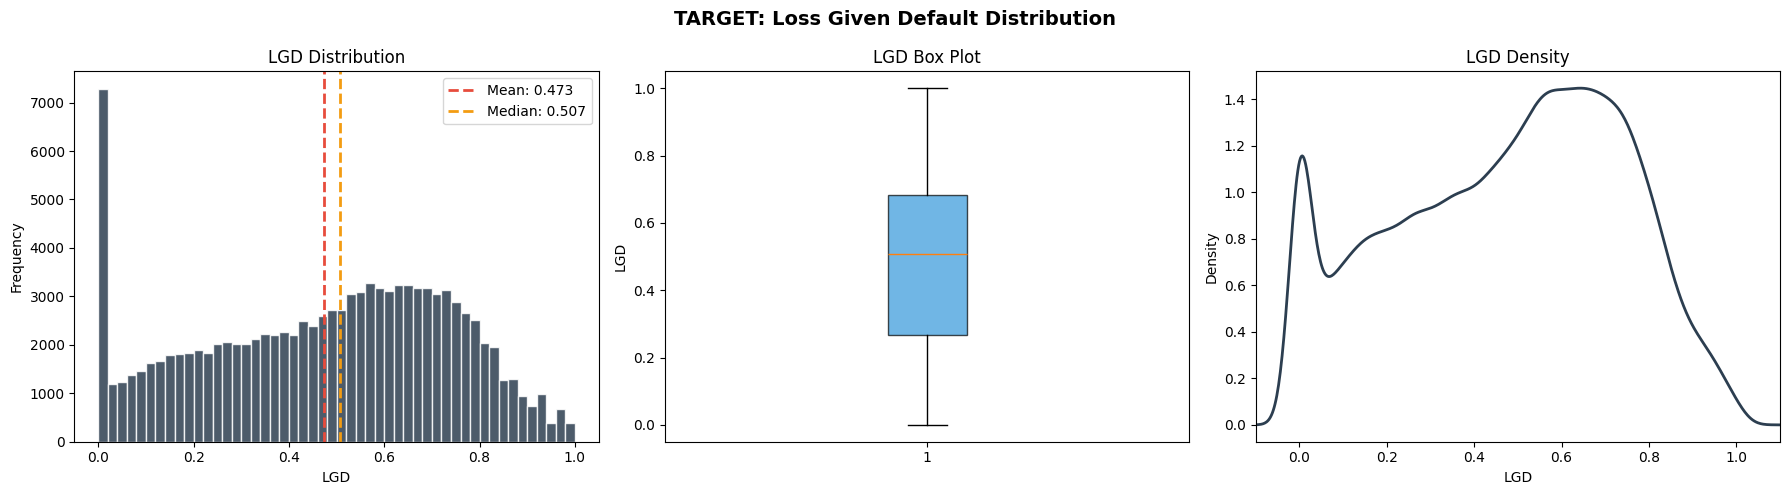

In [ ]:
print("\n---Target Variable Distribution ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['LGD'], bins=50, color='#2c3e50', edgecolor='white', alpha=0.85)
axes[0].axvline(df['LGD'].mean(), color='#e74c3c', ls='--', lw=2,
                label=f"Mean: {df['LGD'].mean():.3f}")
axes[0].axvline(df['LGD'].median(), color='#f39c12', ls='--', lw=2,
                label=f"Median: {df['LGD'].median():.3f}")
axes[0].set_xlabel('LGD')
axes[0].set_ylabel('Frequency')
axes[0].set_title('LGD Distribution')
axes[0].legend()

axes[1].boxplot(df['LGD'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_ylabel('LGD')
axes[1].set_title('LGD Box Plot')

try:
    df['LGD'].plot.kde(ax=axes[2], color='#2c3e50', lw=2)
except:
    axes[2].hist(df['LGD'], bins=50, density=True, color='#2c3e50', alpha=0.7)
axes[2].set_xlabel('LGD')
axes[2].set_title('LGD Density')
axes[2].set_xlim(-0.1, 1.1)

plt.suptitle('TARGET: Loss Given Default Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_lgd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()



--- Missing Values Analysis ---
   Features with missing values: 45 / 106

   Top 20 by missing %:
                                         Count    Pct
sec_app_mths_since_last_major_derog  109456  99.11
sec_app_revol_util                   108236  98.01
sec_app_chargeoff_within_12_mths     108175  97.95
sec_app_num_rev_accts                108175  97.95
sec_app_open_acc                     108175  97.95
sec_app_mort_acc                     108175  97.95
sec_app_inq_last_6mths               108175  97.95
sec_app_collections_12_mths_ex_med   108175  97.95
sec_app_earliest_cr_line             108175  97.95
sec_app_fico_range_high              108175  97.95
sec_app_open_act_il                  108175  97.95
revol_bal_joint                      108175  97.95
sec_app_fico_range_low               108175  97.95
verification_status_joint            107808  97.62
dti_joint                            107800  97.61
annual_inc_joint                     107800  97.61
mths_since_last_record        

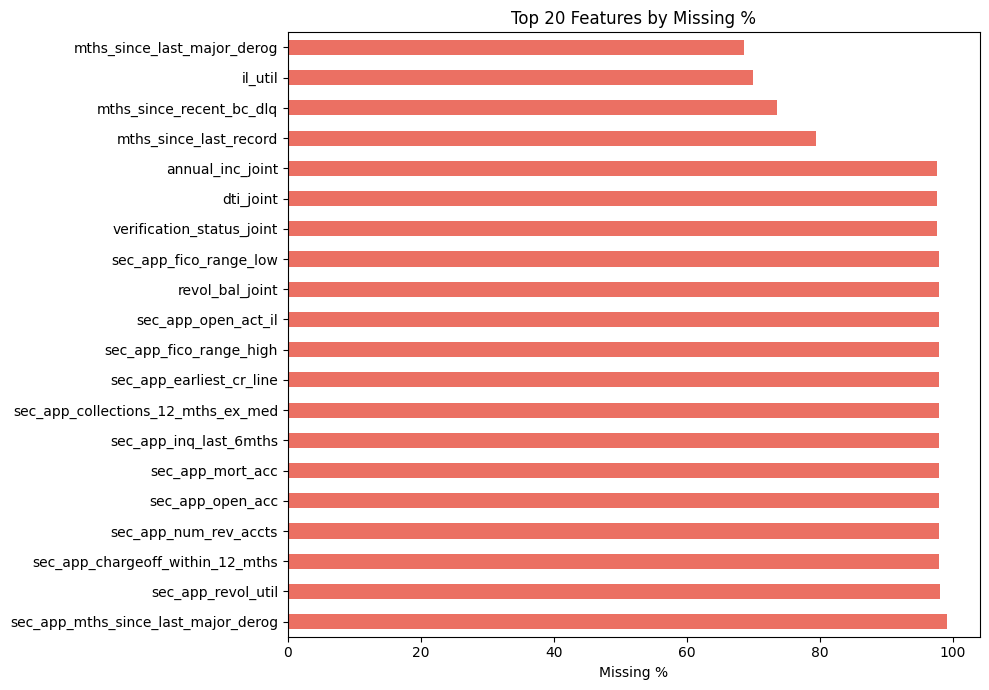

In [ ]:
print("\n--- Missing Values Analysis ---")

missing = df[features].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Count': missing, 'Pct': missing_pct
}).sort_values('Pct', ascending=False)

missing_sig = missing_df[missing_df['Pct'] > 0]
print(f"   Features with missing values: {len(missing_sig)} / {len(features)}")

if len(missing_sig) > 0:
    print(f"\n   Top 20 by missing %:")
    print(f"   {missing_sig.head(20)}")

    # Visualize top missing
    top_missing = missing_sig.head(20)
    fig, ax = plt.subplots(figsize=(10, max(4, len(top_missing)*0.35)))
    top_missing['Pct'].plot.barh(ax=ax, color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Missing %')
    ax.set_title('Top 20 Features by Missing %')
    plt.tight_layout()
    plt.savefig('02_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
high_missing = missing_df[missing_df['Pct'] > 70].index.tolist()
if high_missing:
    print(f"   Dropping {len(high_missing)} columns with > 70% missing:")
    for c in high_missing:
        print(f"     • {c} ({missing_df.loc[c, 'Pct']:.1f}%)")
    df = df.drop(columns=[c for c in high_missing if c in df.columns and c != 'LGD'])

   Dropping 19 columns with > 70% missing:
     • sec_app_mths_since_last_major_derog (99.1%)
     • sec_app_revol_util (98.0%)
     • sec_app_chargeoff_within_12_mths (98.0%)
     • sec_app_num_rev_accts (98.0%)
     • sec_app_open_acc (98.0%)
     • sec_app_mort_acc (98.0%)
     • sec_app_inq_last_6mths (98.0%)
     • sec_app_collections_12_mths_ex_med (98.0%)
     • sec_app_earliest_cr_line (98.0%)
     • sec_app_fico_range_high (98.0%)
     • sec_app_open_act_il (98.0%)
     • revol_bal_joint (98.0%)
     • sec_app_fico_range_low (98.0%)
     • verification_status_joint (97.6%)
     • dti_joint (97.6%)
     • annual_inc_joint (97.6%)
     • mths_since_last_record (79.3%)
     • mths_since_recent_bc_dlq (73.5%)
     • il_util (70.0%)


In [ ]:
df.shape

(110435, 88)

In [ ]:
# df.to_csv("Datasetwithlessmissingdata.csv", index = False)

In [ ]:
df = pd.read_csv("/content/Datasetwithlessmissingdata.csv")

In [ ]:
df.shape

(110435, 88)

In [ ]:
# update the feature list
features = [c for c in df.columns if c != 'LGD']
cat_feats = [features for features in df.columns if df[features].dtypes=="O"]
numeric_feats = [features for features in df.columns if df[features].dtypes!="O"]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110435 entries, 0 to 110434
Data columns (total 88 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   loan_amnt                       110435 non-null  float64
 1   funded_amnt                     110435 non-null  float64
 2   funded_amnt_inv                 110435 non-null  float64
 3   term                            110435 non-null  object 
 4   int_rate                        110435 non-null  float64
 5   installment                     110435 non-null  float64
 6   grade                           110435 non-null  object 
 7   sub_grade                       110435 non-null  object 
 8   emp_length                      101487 non-null  object 
 9   home_ownership                  110435 non-null  object 
 10  annual_inc                      110435 non-null  float64
 11  verification_status             110435 non-null  object 
 12  issue_d         

In [ ]:
mths_since_cols = [c for c in numeric_feats if 'mths_since' in c or 'mo_sin' in c]
print(f"\n   'Months since' columns (fill -1 = never happened): {len(mths_since_cols)}")
for col in mths_since_cols:
    pct = df[col].isnull().mean() * 100
    if pct > 0:
        df[col] = df[col].fillna(-1)
        print(f"     • {col}: filled {pct:.1f}% with -1")


   'Months since' columns (fill -1 = never happened): 10
     • mths_since_last_delinq: filled 47.2% with -1
     • mths_since_last_major_derog: filled 68.6% with -1
     • mths_since_rcnt_il: filled 66.6% with -1
     • mo_sin_old_il_acct: filled 3.0% with -1
     • mths_since_recent_bc: filled 1.1% with -1
     • mths_since_recent_inq: filled 7.1% with -1
     • mths_since_recent_revol_delinq: filled 63.5% with -1


In [ ]:
other_numeric = [c for c in numeric_feats if c not in mths_since_cols]
for col in other_numeric:
    if df[col].isnull().any():
        median_val = df[col].median()
        pct = df[col].isnull().mean() * 100
        df[col] = df[col].fillna(median_val)
        print(f"     • {col}: filled {pct:.1f}% with median ({median_val:.2f})")

     • dti: filled 0.0% with median (20.47)
     • revol_util: filled 0.1% with median (54.30)
     • open_acc_6m: filled 65.4% with median (1.00)
     • open_act_il: filled 65.4% with median (2.00)
     • open_il_12m: filled 65.4% with median (1.00)
     • open_il_24m: filled 65.4% with median (1.00)
     • total_bal_il: filled 65.4% with median (24207.50)
     • open_rv_12m: filled 65.4% with median (1.00)
     • open_rv_24m: filled 65.4% with median (3.00)
     • max_bal_bc: filled 65.4% with median (3837.00)
     • all_util: filled 65.4% with median (63.00)
     • inq_fi: filled 65.4% with median (1.00)
     • total_cu_tl: filled 65.4% with median (0.00)
     • inq_last_12m: filled 65.4% with median (2.00)
     • avg_cur_bal: filled 0.0% with median (5614.00)
     • bc_open_to_buy: filled 1.1% with median (3663.00)
     • bc_util: filled 1.2% with median (67.00)
     • num_tl_120dpd_2m: filled 5.8% with median (0.00)
     • percent_bc_gt_75: filled 1.2% with median (50.00)


In [ ]:
for col in cat_feats:
    if df[col].isnull().any():
        pct = df[col].isnull().mean() * 100
        df[col] = df[col].fillna('Unknown')
        print(f"     • {col}: filled {pct:.1f}% with 'Unknown'")

     • emp_length: filled 8.1% with 'Unknown'


In [ ]:
print(f"\n   Remaining missing values: {df[features].isnull().sum().sum()}")



   Remaining missing values: 0


In [ ]:
cat_analysis = ['grade', 'sub_grade', 'term', 'home_ownership', 'purpose',
                'verification_status', 'application_type']
cat_analysis = [c for c in cat_analysis if c in df.columns]

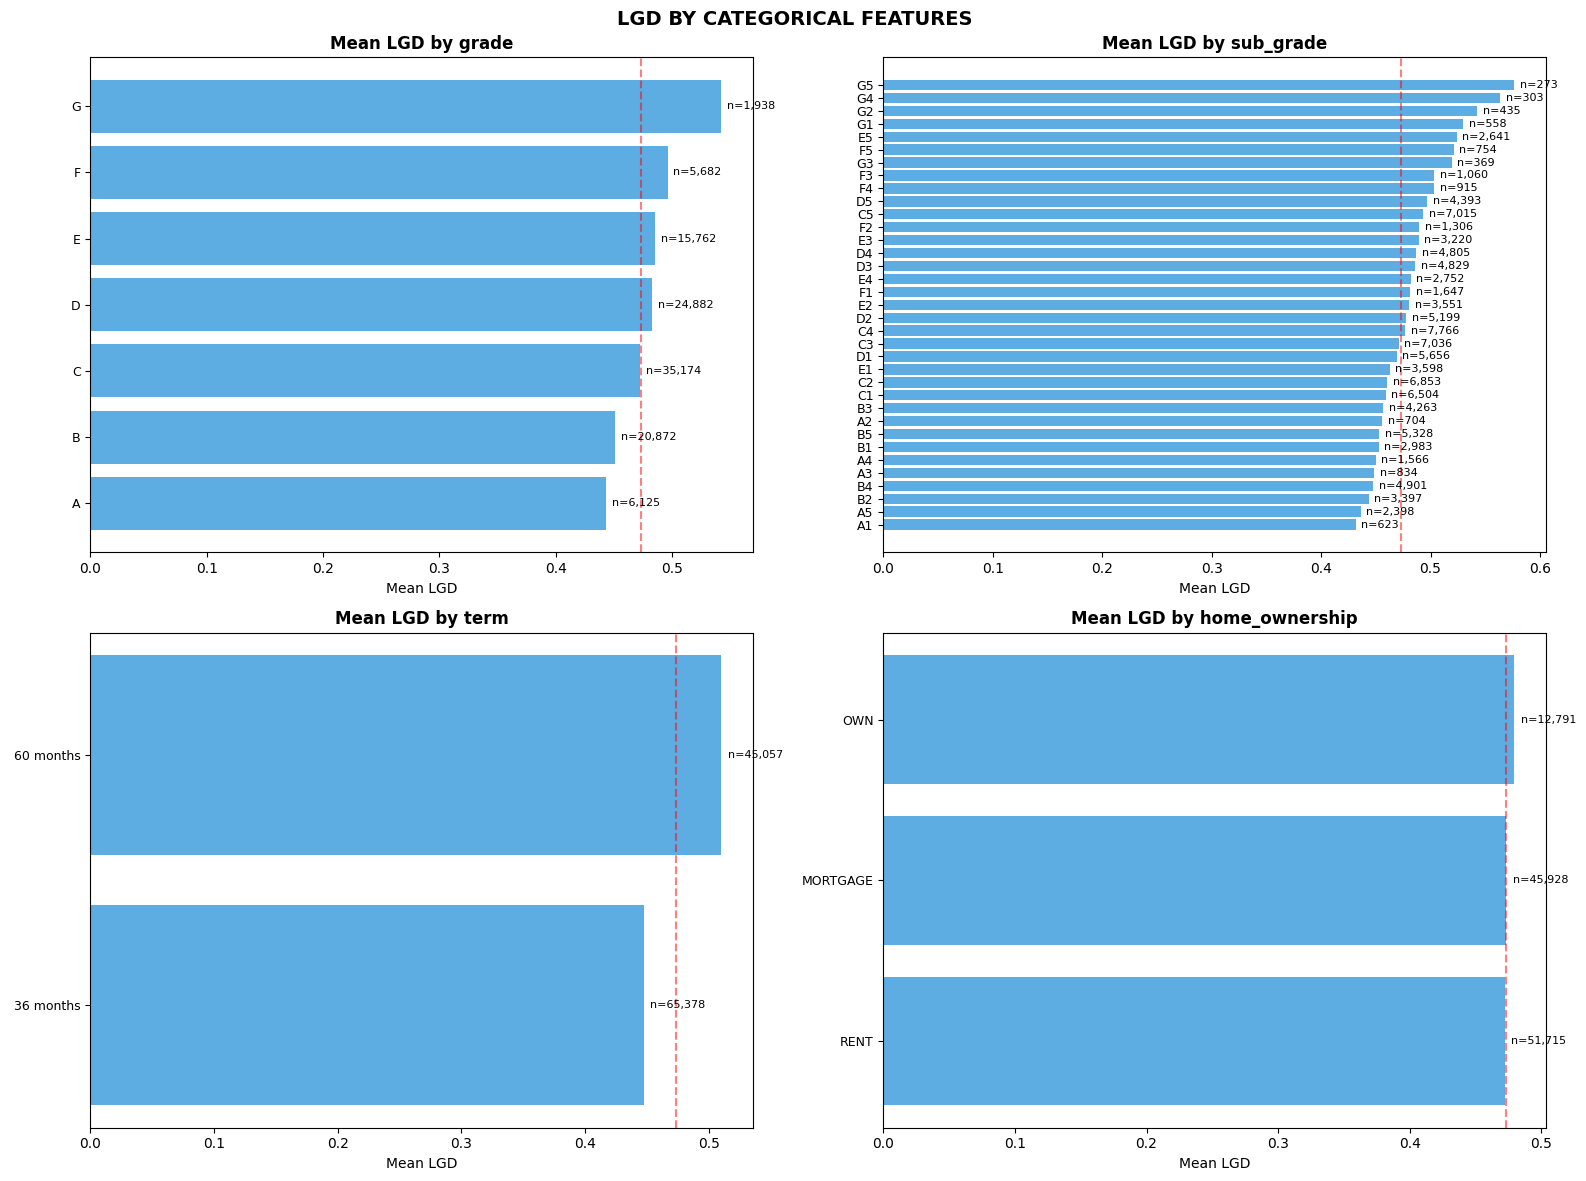

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_analysis[:4]):
    grouped = df.groupby(col)['LGD'].agg(['mean', 'count']).sort_values('mean')
    # Only show categories with >= 20 observations
    grouped = grouped[grouped['count'] >= 20]

    bars = axes[i].barh(range(len(grouped)), grouped['mean'],
                        color='#3498db', alpha=0.8)
    axes[i].set_yticks(range(len(grouped)))
    axes[i].set_yticklabels(grouped.index, fontsize=9)
    axes[i].set_xlabel('Mean LGD')
    axes[i].set_title(f'Mean LGD by {col}', fontweight='bold')
    axes[i].axvline(df['LGD'].mean(), color='red', ls='--', alpha=0.5)


    for j, (mean_val, count) in enumerate(zip(grouped['mean'], grouped['count'])):
        axes[i].text(mean_val + 0.005, j, f'n={count:,}', va='center', fontsize=8)

plt.suptitle('LGD BY CATEGORICAL FEATURES', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_lgd_by_categories.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
if 'grade' in df.columns:
    print(f"\n   LGD by Grade:")
    grade_lgd = df.groupby('grade')['LGD'].agg(['mean', 'median', 'count'])
    grade_lgd = grade_lgd.sort_index()
    print(f"   {grade_lgd.to_string()}")


   LGD by Grade:
              mean    median  count
grade                           
A      0.443056  0.447746   6125
B      0.450892  0.471347  20872
C      0.472428  0.507368  35174
D      0.482668  0.519962  24882
E      0.485731  0.527527  15762
F      0.496279  0.546063   5682
G      0.542576  0.594881   1938


In [ ]:
key_numeric = ['int_rate', 'loan_amnt', 'annual_inc', 'dti',
               'fico_range_low', 'revol_util', 'installment', 'total_acc']
key_numeric = [c for c in key_numeric if c in df.columns]

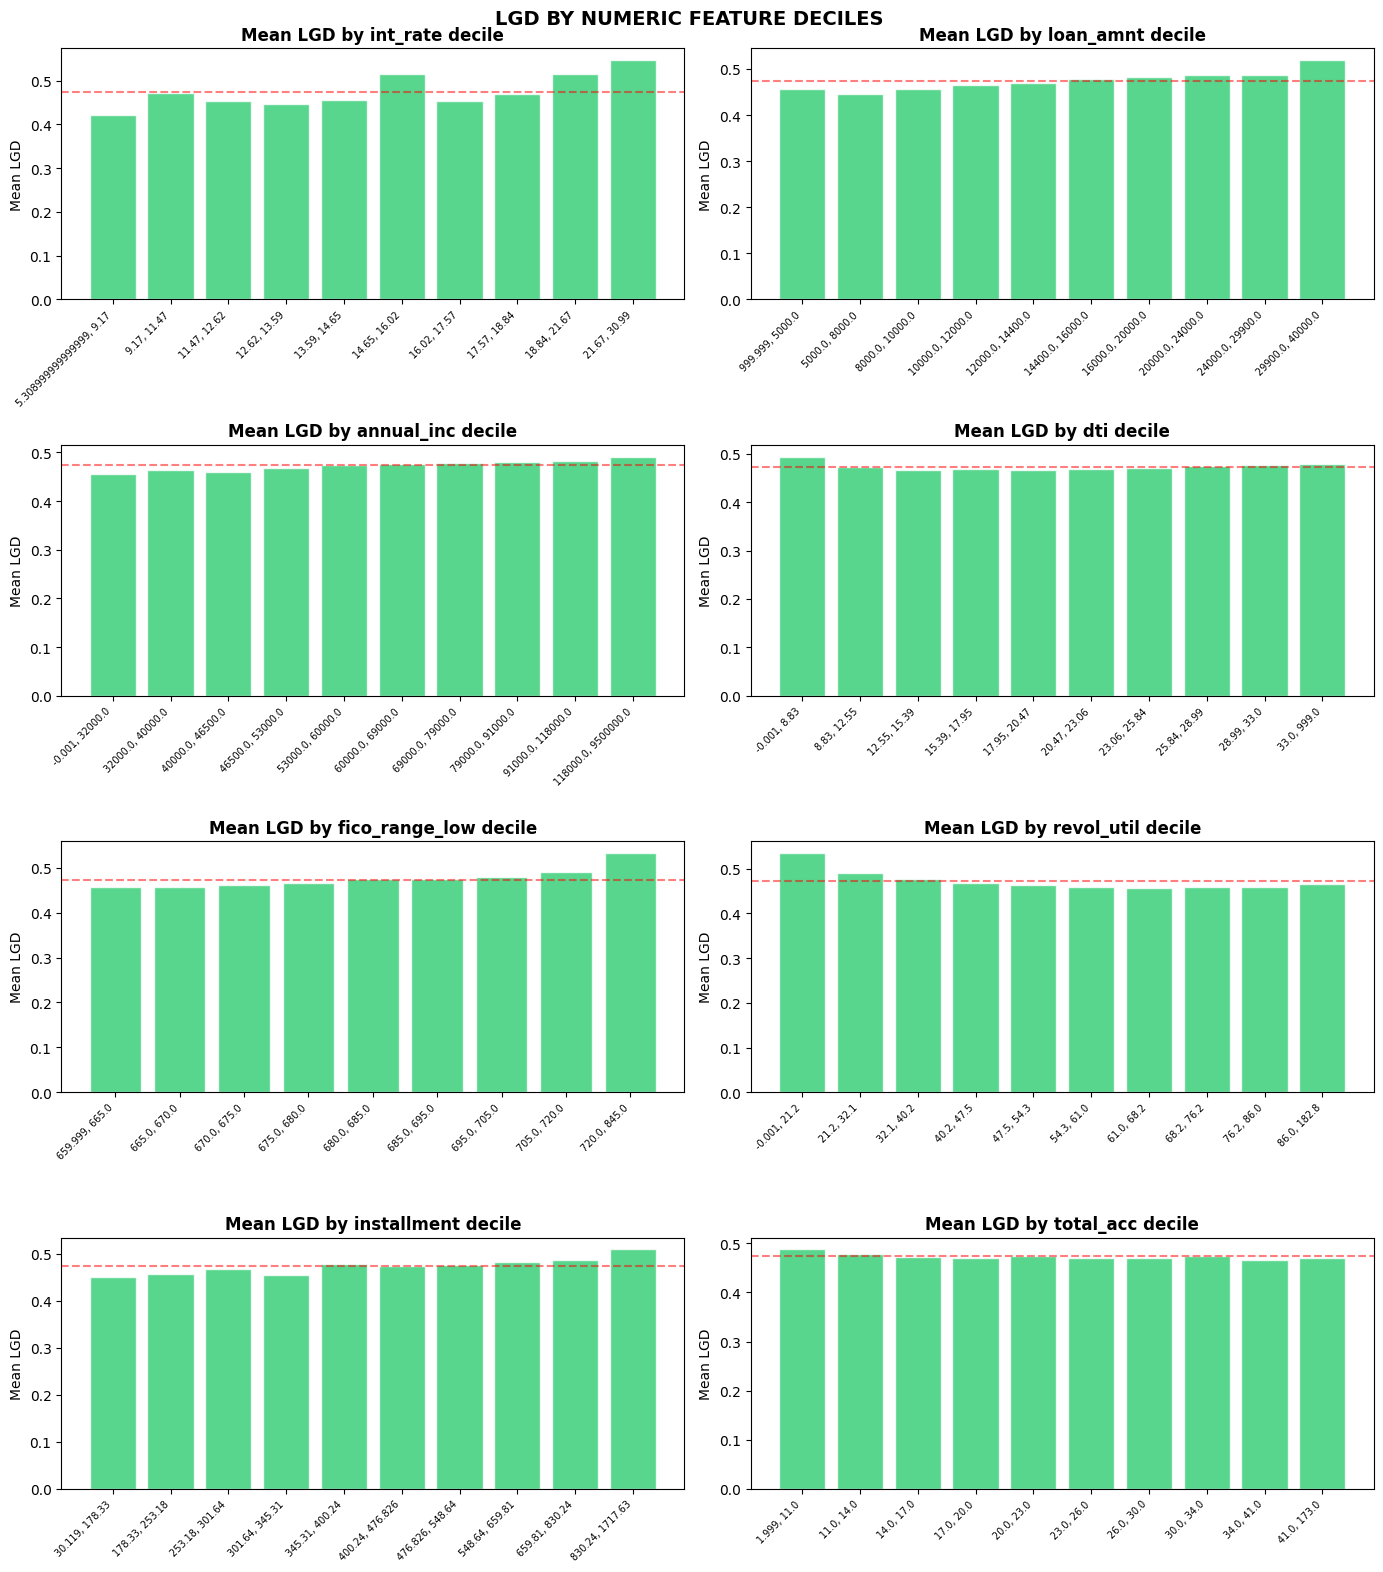

In [ ]:
if len(key_numeric) > 0:
    n_cols = 2
    n_rows = (len(key_numeric) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(key_numeric):
        # Bin into deciles and plot mean LGD per bin
        try:
            df['_bin'] = pd.qcut(df[col], q=10, duplicates='drop')
            binned = df.groupby('_bin')['LGD'].mean()
            axes[i].bar(range(len(binned)), binned.values,
                       color='#2ecc71', alpha=0.8, edgecolor='white')
            axes[i].set_xticks(range(len(binned)))
            labels = [str(x).replace('(', '').replace(']', '') for x in binned.index]
            axes[i].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
            axes[i].set_ylabel('Mean LGD')
            axes[i].set_title(f'Mean LGD by {col} decile', fontweight='bold')
            axes[i].axhline(df['LGD'].mean(), color='red', ls='--', alpha=0.5)
            df.drop(columns='_bin', inplace=True)
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Could not plot {col}\n{str(e)[:50]}',
                        transform=axes[i].transAxes, ha='center')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('LGD BY NUMERIC FEATURE DECILES', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('04_lgd_by_numerics.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
len(numeric_feats)

74

In [ ]:
numeric_feats = df[features].select_dtypes(include=[np.number]).columns.tolist()

In [ ]:
len(numeric_feats)

73

In [ ]:
corr_with_lgd = df[numeric_feats + ['LGD']].corr()['LGD'].drop('LGD')
corr_sorted = corr_with_lgd.abs().sort_values(ascending=False)


   Top 20 features by |correlation| with LGD:
   + LGD_RAW                                  +0.9957
   + mths_since_rcnt_il                       +0.1561
   + total_cu_tl                              +0.1322
   + int_rate                                 +0.1216
   + open_il_24m                              +0.1069
   + fico_range_high                          +0.0880
   + fico_range_low                           +0.0880
   - bc_util                                  -0.0841
   + max_bal_bc                               +0.0840
   + bc_open_to_buy                           +0.0791
   + funded_amnt_inv                          +0.0782
   + funded_amnt                              +0.0782
   + loan_amnt                                +0.0782
   - num_rev_tl_bal_gt_0                      -0.0709
   - all_util                                 -0.0707
   - revol_util                               -0.0700
   - num_actv_rev_tl                          -0.0668
   - percent_bc_gt_75              

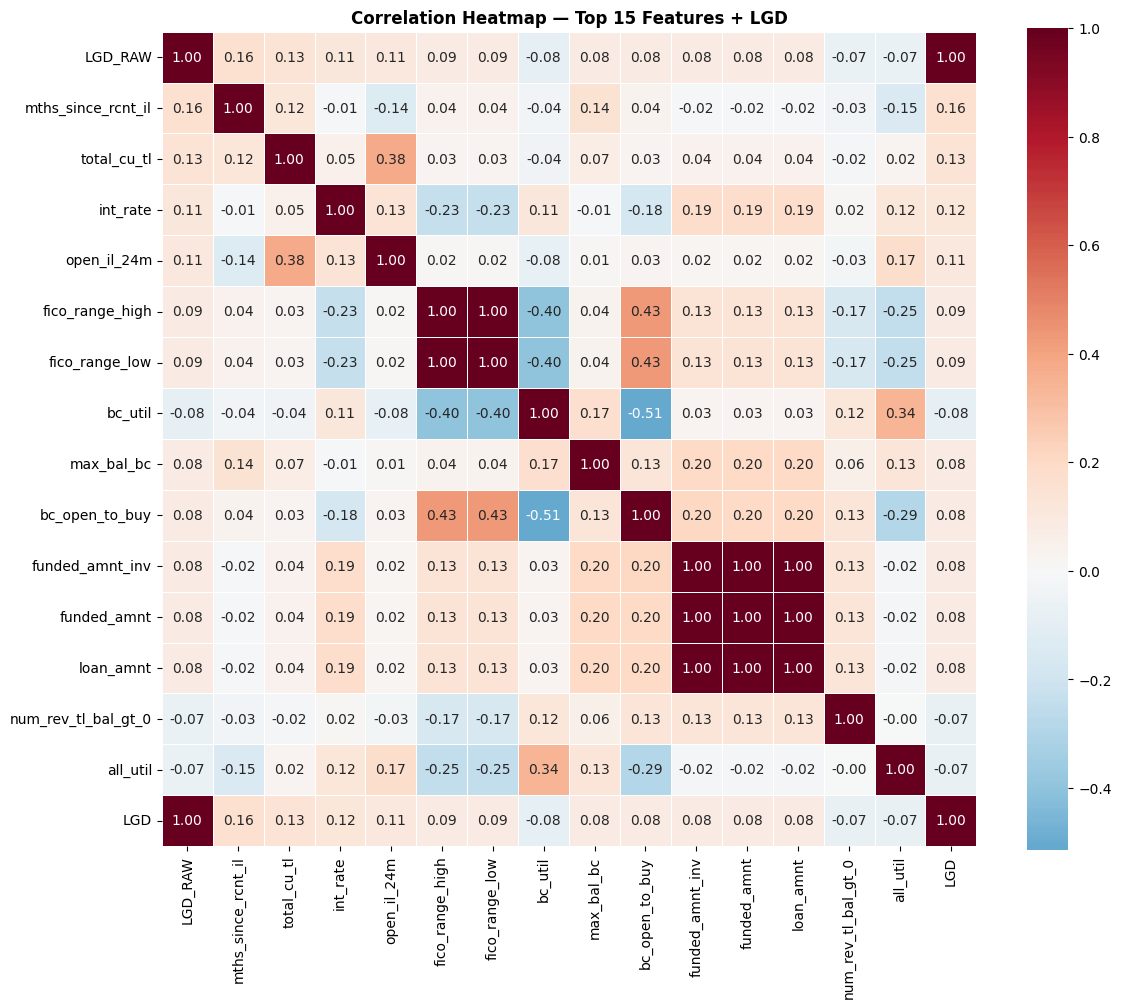

In [ ]:
print(f"\n   Top 20 features by |correlation| with LGD:")
for feat, val in corr_sorted.head(20).items():
    direction = '+' if corr_with_lgd[feat] > 0 else '-'
    print(f"   {direction} {feat:40s} {corr_with_lgd[feat]:+.4f}")

# Plot correlation heatmap of top features
top_corr_feats = corr_sorted.head(15).index.tolist()
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[top_corr_feats + ['LGD']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top 15 Features + LGD', fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


--- 5.7: LGD Over Time ---

   LGD by Origination Year:
                   mean    median  count
issue_year                           
2015        0.416739  0.429827  76094
2016        0.476036  0.480272  15955
2017        0.658162  0.656452  12981
2018        0.819433  0.815653   5405


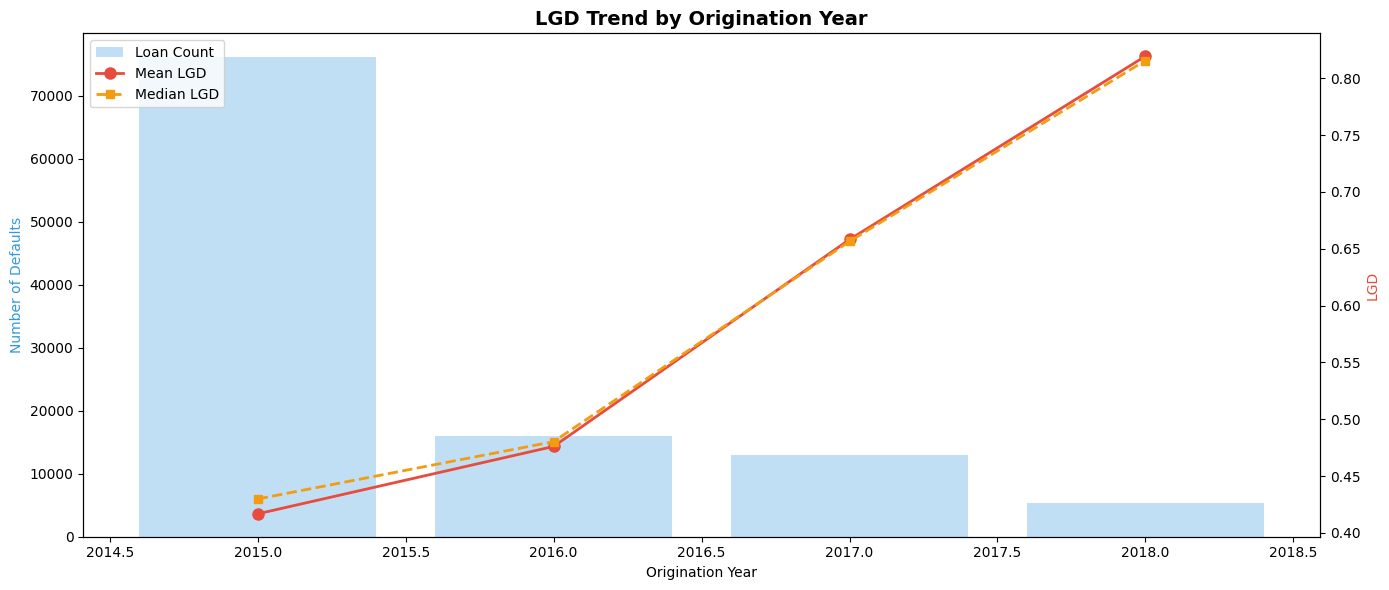

In [ ]:
print("\n--- 5.7: LGD Over Time ---")

if 'issue_d' in df.columns:
    # Parse issue date
    df['issue_d'] = pd.to_datetime(df['issue_d'], format='mixed', errors='coerce')
    df['issue_year'] = df['issue_d'].dt.year
    df['issue_month_num'] = df['issue_d'].dt.to_period('M')

    yearly_lgd = df.groupby('issue_year')['LGD'].agg(['mean', 'median', 'count'])
    print(f"\n   LGD by Origination Year:")
    print(f"   {yearly_lgd.to_string()}")

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()

    ax1.bar(yearly_lgd.index, yearly_lgd['count'], alpha=0.3, color='#3498db',
            label='Loan Count')
    ax2.plot(yearly_lgd.index, yearly_lgd['mean'], 'o-', color='#e74c3c',
             lw=2, markersize=8, label='Mean LGD')
    ax2.plot(yearly_lgd.index, yearly_lgd['median'], 's--', color='#f39c12',
             lw=2, markersize=6, label='Median LGD')

    ax1.set_xlabel('Origination Year')
    ax1.set_ylabel('Number of Defaults', color='#3498db')
    ax2.set_ylabel('LGD', color='#e74c3c')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title('LGD Trend by Origination Year', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('06_lgd_time_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
# --- 6.1: FICO score (average of range) ---
if 'fico_range_low' in df.columns and 'fico_range_high' in df.columns:
    df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
    print("   fico_score = avg(fico_range_low, fico_range_high)")

# --- 6.2: Loan affordability ratios ---
if 'loan_amnt' in df.columns and 'annual_inc' in df.columns:
    df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)  # +1 avoid div/0
    print("   loan_to_income = loan_amnt / annual_inc")

if 'installment' in df.columns and 'annual_inc' in df.columns:
    df['installment_burden'] = df['installment'] / (df['annual_inc'] / 12 + 1)
    print("   installment_burden = installment / monthly_income")

# --- 6.3: Credit utilization ---
if 'revol_bal' in df.columns and 'total_rev_hi_lim' in df.columns:
    df['credit_utilization'] = df['revol_bal'] / (df['total_rev_hi_lim'] + 1)
    df['credit_utilization'] = df['credit_utilization'].clip(0, 5)  # cap outliers
    print("   credit_utilization = revol_bal / total_rev_hi_lim")

# --- 6.4: Credit history length ---
if 'earliest_cr_line' in df.columns and 'issue_d' in df.columns:
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'],
                                             format='mixed', errors='coerce')
    df['credit_history_years'] = (
        (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25
    )
    df['credit_history_years'] = df['credit_history_years'].clip(0, 60)
    print("   credit_history_years = issue_d - earliest_cr_line")

# --- 6.5: Open account ratio ---
if 'open_acc' in df.columns and 'total_acc' in df.columns:
    df['open_acc_ratio'] = df['open_acc'] / (df['total_acc'] + 1)
    print("   open_acc_ratio = open_acc / total_acc")

# --- 6.6: Delinquency flags ---
if 'delinq_2yrs' in df.columns:
    df['has_recent_delinq'] = (df['delinq_2yrs'] > 0).astype(int)
    print("   has_recent_delinq = binary flag")

if 'pub_rec_bankruptcies' in df.columns:
    df['has_bankruptcy'] = (df['pub_rec_bankruptcies'] > 0).astype(int)
    print("   has_bankruptcy = binary flag")

if 'pub_rec' in df.columns:
    df['has_public_record'] = (df['pub_rec'] > 0).astype(int)
    print("   has_public_record = binary flag")

# --- 6.7: Interest rate as numeric ---
if 'int_rate' in df.columns and df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)
    print("   int_rate converted to numeric")

# --- 6.8: Employment length as numeric ---
if 'emp_length' in df.columns:
    emp_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8, '9 years': 9, '10+ years': 10
    }
    df['emp_length_num'] = df['emp_length'].map(emp_map)
    df['emp_length_num'] = df['emp_length_num'].fillna(-1)  # unknown
    print("   emp_length_num = numeric encoding")

# --- 6.9: Term as numeric ---
if 'term' in df.columns:
    df['term_num'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)
    print("   term_num = numeric (36 or 60)")

print(f"\n   Total features after engineering: {len(df.columns) - 1}")


   fico_score = avg(fico_range_low, fico_range_high)
   loan_to_income = loan_amnt / annual_inc
   installment_burden = installment / monthly_income
   credit_utilization = revol_bal / total_rev_hi_lim
   credit_history_years = issue_d - earliest_cr_line
   open_acc_ratio = open_acc / total_acc
   has_recent_delinq = binary flag
   has_bankruptcy = binary flag
   has_public_record = binary flag
   emp_length_num = numeric encoding
   term_num = numeric (36 or 60)

   Total features after engineering: 100


In [ ]:
drop_after_engineering = [
    'issue_d', 'issue_month_num', 'earliest_cr_line',  # dates (used for features)
    'fico_range_low', 'fico_range_high',  # replaced by fico_score
    'emp_length', 'term',  # replaced by numeric versions
    'zip_code',  # too many categories (partial zip)
    'addr_state',  # high cardinality; could use but adds complexity
    'sub_grade',  # highly correlated with grade + int_rate
    'funded_amnt', 'funded_amnt_inv', 'loan_amnt',  # keep loan_to_income instead
]

In [ ]:
drop_existing = [c for c in drop_after_engineering if c in df.columns]
df = df.drop(columns=drop_existing)
print(f"   Dropped {len(drop_existing)} redundant/processed columns")

   Dropped 13 redundant/processed columns


In [ ]:
#Encode categorical variables
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'LGD']  # safety check

print(f"\n   Encoding {len(cat_cols)} categorical columns:")
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"     • {col}: {n_unique} unique values")

# One-hot encode
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(f"\n   Final dataset shape: {df.shape}")
print(f"   Features: {df.shape[1] - 1}")

# --- 7.3: Remove any remaining infinities ---
df = df.replace([np.inf, -np.inf], np.nan)
remaining_null = df.isnull().sum().sum()
if remaining_null > 0:
    print(f"   Filling {remaining_null} remaining NaN/inf values with 0")
    df = df.fillna(0)


   Encoding 7 categorical columns:
     • grade: 7 unique values
     • home_ownership: 4 unique values
     • verification_status: 3 unique values
     • purpose: 13 unique values
     • initial_list_status: 2 unique values
     • application_type: 2 unique values
     • disbursement_method: 2 unique values

   Final dataset shape: (110435, 107)
   Features: 106


In [ ]:
final_features = [c for c in df.columns if c not in ['LGD', 'issue_year']]
print(f"\n   ✅ Final feature count: {len(final_features)}")


   ✅ Final feature count: 105


In [ ]:
listLGD = [ c for c in df.columns  if 'LGD' in c]
listLGD

['LGD', 'LGD_RAW']

In [ ]:
if 'issue_year' in df.columns and df['issue_year'].nunique() > 2:
    years = sorted(df['issue_year'].dropna().unique())
    print(f"   Available years: {years}")

    # Find a reasonable split point
    # Use first ~70% of years for train, next ~15% for validation, last ~15% for test
    if len(years) >= 4:
        split_year_val = years[int(len(years) * 0.65)]
        split_year_test = years[int(len(years) * 0.80)]

        train_mask = df['issue_year'] <= split_year_val
        val_mask = (df['issue_year'] > split_year_val) & (df['issue_year'] <= split_year_test)
        test_mask = df['issue_year'] > split_year_test

        print(f"\n   Train: issue_year <= {split_year_val}")
        print(f"   Val:   issue_year {split_year_val+1}-{split_year_test}")
        print(f"   Test:  issue_year > {split_year_test}")
    else:
        # Not enough years, use 70/15/15 random split as fallback
        from sklearn.model_selection import train_test_split
        print("\n   Not enough year range for time split — using random split")
        train_idx, temp_idx = train_test_split(df.index, test_size=0.3, random_state=42)
        val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
        train_mask = df.index.isin(train_idx)
        val_mask = df.index.isin(val_idx)
        test_mask = df.index.isin(test_idx)
else:
    from sklearn.model_selection import train_test_split
    print("   No issue_year column — using random split (70/15/15)")
    train_idx, temp_idx = train_test_split(df.index, test_size=0.3, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
    train_mask = df.index.isin(train_idx)
    val_mask = df.index.isin(val_idx)
    test_mask = df.index.isin(test_idx)

# Create splits
X_train = df.loc[train_mask, final_features]
y_train = df.loc[train_mask, 'LGD']
X_val = df.loc[val_mask, final_features]
y_val = df.loc[val_mask, 'LGD']
X_test = df.loc[test_mask, final_features]
y_test = df.loc[test_mask, 'LGD']

print(f"\n   Train: {len(X_train):,} loans (mean LGD: {y_train.mean():.4f})")
print(f"   Val:   {len(X_val):,} loans (mean LGD: {y_val.mean():.4f})")
print(f"   Test:  {len(X_test):,} loans (mean LGD: {y_test.mean():.4f})")

# Drop issue_year from features if present
if 'issue_year' in X_train.columns:
    X_train = X_train.drop(columns=['issue_year'])
    X_val = X_val.drop(columns=['issue_year'])
    X_test = X_test.drop(columns=['issue_year'])
    final_features = [f for f in final_features if f != 'issue_year']


   Available years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]

   Train: issue_year <= 2017
   Val:   issue_year 2018-2018
   Test:  issue_year > 2018

   Train: 105,030 loans (mean LGD: 0.4556)
   Val:   5,405 loans (mean LGD: 0.8194)
   Test:  0 loans (mean LGD: nan)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [ ]:
## Beginning Model Training
models = {
    # "Linear Regression": LinearRegression(),
    # "Lasso": Lasso(),
    # "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),

}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    print('='*35)
    print('\n')

ValueError: Found array with 0 sample(s) (shape=(0, 105)) while a minimum of 1 is required by KNeighborsRegressor.